In [ ]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

#EDA

# Dataset:
# https://www.kaggle.com/datasets/lion8beasttmkc/nasa-near-earth-asteroids-dataset
df = pd.read_csv('asteroids_data.csv')
print(df.head())
#print(df.info())
#пропущенные значения (Missing values)
#print(df.isna().sum())

        id   neo_id                         name    short_name  designation  \
0  2001620  2001620    1620 Geographos (1951 RA)    Geographos         1620   
1  2001863  2001863      1863 Antinous (1948 EA)      Antinous         1863   
2  2001915  2001915  1915 Quetzalcoatl (1953 EA)  Quetzalcoatl         1915   
3  2001917  2001917          1917 Cuyo (1968 AA)          Cuyo         1917   
4  2002063  2002063       2063 Bacchus (1977 HB)       Bacchus         2063   

                                            nasa_url  magnitude  \
0  https://ssd.jpl.nasa.gov/tools/sbdb_lookup.htm...      15.26   
1  https://ssd.jpl.nasa.gov/tools/sbdb_lookup.htm...      15.35   
2  https://ssd.jpl.nasa.gov/tools/sbdb_lookup.htm...      18.38   
3  https://ssd.jpl.nasa.gov/tools/sbdb_lookup.htm...      14.38   
4  https://ssd.jpl.nasa.gov/tools/sbdb_lookup.htm...      17.21   

   potentially_hazardous                                close_approach_data  \
0                   True  [{'close_approach

In [6]:
df['potentially_hazardous'].value_counts()

potentially_hazardous
False    1467
True      533
Name: count, dtype: int64

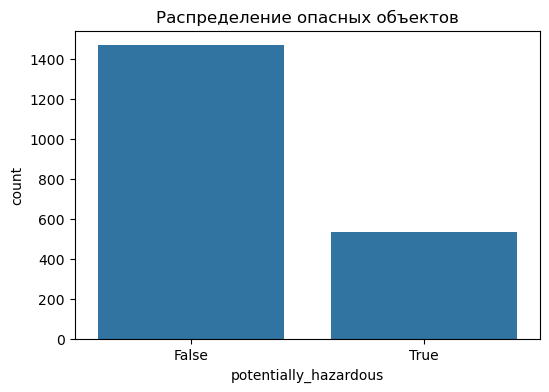

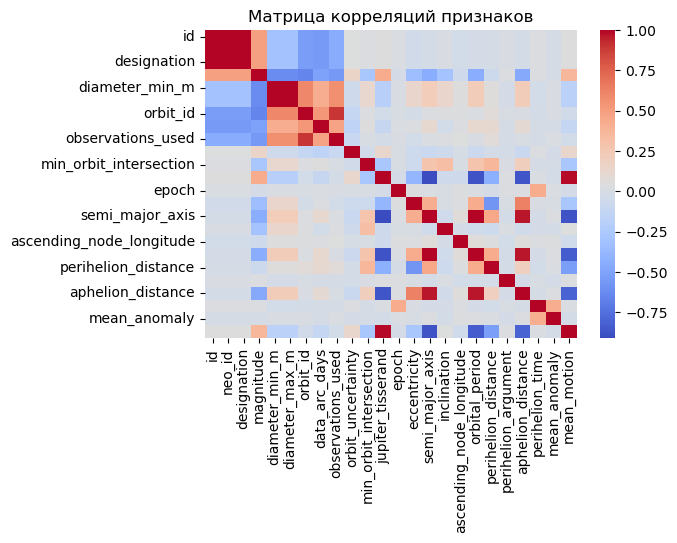

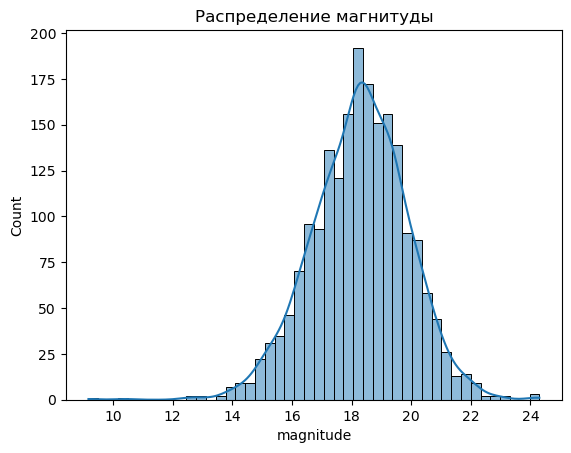

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(x='potentially_hazardous', data=df)
plt.title('Распределение опасных объектов')
plt.show()

plt.figure(figsize=(6, 4))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), cmap='coolwarm', annot=False)
plt.title('Матрица корреляций признаков')
plt.show()

sns.histplot(df['magnitude'], kde=True)
plt.title('Распределение магнитуды')
plt.show()

In [8]:
SEED = 42
MAX_ITTER = 1000
np.random.seed(SEED)
random.seed(SEED)

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler#, LabelEncoder
from sklearn.linear_model import LogisticRegression
#from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import RidgeClassifierCV

In [10]:
y = df['potentially_hazardous'].astype(int)
df_short = df.drop(columns=['id', 'neo_id', 'name', 'short_name', 'nasa_url', 'potentially_hazardous', 'sentry', 'api_url', 'close_approach_data', 
                            'orbit_class_desc', 'orbit_class_range', 'sentry_data', 'equinox', 'orbit_determination_date', 'first_observation_date', 
                            'last_observation_date'])

In [11]:
y.head(5), df_short.head(5)

(0    1
 1    0
 2    0
 3    0
 4    0
 Name: potentially_hazardous, dtype: int64,
    designation  magnitude  diameter_min_m  diameter_max_m  orbit_id  \
 0         1620      15.26     2358.060680     5272.783976       882   
 1         1863      15.35     2262.324906     5058.712276       305   
 2         1915      18.38      560.473362     1253.256538        13   
 3         1917      14.38     3536.347843     7907.514169       654   
 4         2063      17.21      960.627415     2148.028201       258   
 
    data_arc_days  observations_used  orbit_uncertainty  \
 0          27243               9183                  0   
 1          28532               1804                  0   
 2          24702                 55                  0   
 3          26281               4164                  0   
 4          17584               1561                  0   
 
    min_orbit_intersection  jupiter_tisserand  ...  inclination  \
 0                0.029359              5.074  ...    13.33

In [ ]:
df_short.info()

In [ ]:
df_short['orbit_class_type'].value_counts()

In [14]:
class_type = pd.get_dummies(df_short['orbit_class_type'])
df_short = df_short.drop(labels='orbit_class_type', axis=1)

In [15]:
df_short = pd.concat([df_short,class_type], axis=1)

In [16]:
df_short.shape, y.shape

((2000, 26), (2000,))

In [17]:
X_train, X_test, y_train, y_test = train_test_split(df_short,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=SEED)

len(X_train), len(X_test), len(y_train), len(y_test)

(1600, 400, 1600, 400)

In [18]:
from timeit import default_timer as timer

def print_train_time(start, end):
  total_time = end-start
  print(f'Время тренировки модели: {total_time:.3f} секунд')
  return total_time

In [19]:
def test_metrics(name_model, y_test, y_pred):
  model_acc = accuracy_score(y_true=y_test,
                             y_pred=y_pred)
  model_f1 = f1_score(y_true=y_test,
                      y_pred=y_pred)

  model_precission = precision_score(y_true=y_test,
                                     y_pred = y_pred)

  print(f'Модель {name_model} имеет: Accuracy: {model_acc:.3f}, f1-score:{model_f1:.3f}, precission: {model_precission}')

In [20]:
scaller = StandardScaler()
X_train_scalled, X_test_scalled = scaller.fit_transform(X_train), scaller.transform(X_test)

### Логистическая регрессия

In [21]:
logistic_model = LogisticRegression(random_state=SEED, max_iter=MAX_ITTER)
train_timer_start = timer()

logistic_model.fit(X_train_scalled, y_train)
y_log_preds = logistic_model.predict(X_test_scalled)
train_timer_end = timer()

total_train_timer_logistic = print_train_time(start=train_timer_start,
                                              end=train_timer_end)
test_metrics('Логистическая регрессия', y_test=y_test, y_pred=y_log_preds)

Время тренировки модели: 0.014 секунд
Модель Логистическая регрессия имеет: Accuracy: 0.988, f1-score:0.976, precission: 0.9714285714285714


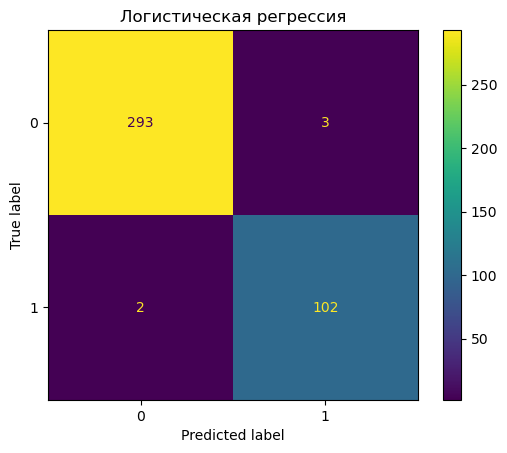

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_log_preds)

disp = ConfusionMatrixDisplay(cm)
disp.plot()

plt.title('Логистическая регрессия')
plt.show()

### RidgeClassifier



In [23]:
ridge_model = RidgeClassifierCV()
train_timer_start = timer()

ridge_model.fit(X_train_scalled, y_train)
y_ridge_preds = ridge_model.predict(X_test_scalled)
train_timer_end = timer()

total_train_timer_ridge = print_train_time(start=train_timer_start,
                                              end=train_timer_end)
test_metrics('RidgeClassifier', y_test=y_test, y_pred=y_ridge_preds)

Время тренировки модели: 0.023 секунд
Модель RidgeClassifier имеет: Accuracy: 0.890, f1-score:0.804, precission: 0.75


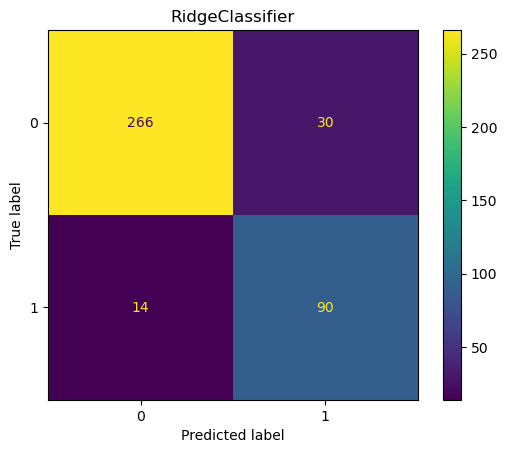

In [24]:
cm = confusion_matrix(y_test, y_ridge_preds)

disp = ConfusionMatrixDisplay(cm)
disp.plot()

plt.title('RidgeClassifier')
plt.show()

### Грандиентный бустинг

In [25]:
boost_model = GradientBoostingClassifier(random_state=SEED)
train_timer_start = timer()

boost_model.fit(X_train_scalled, y_train) 
y_boost_preds = boost_model.predict(X_test_scalled)
train_timer_end = timer()

total_train_timer_boost = print_train_time(start=train_timer_start, end=train_timer_end)
test_metrics('Градиентный бустинг', y_test=y_test, y_pred=y_boost_preds)

Время тренировки модели: 0.551 секунд
Модель Градиентный бустинг имеет: Accuracy: 1.000, f1-score:1.000, precission: 1.0


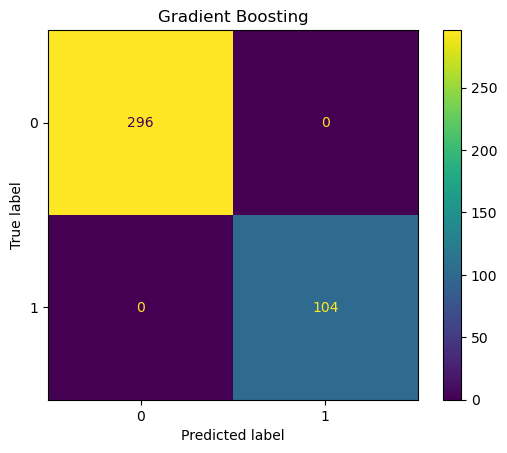

In [26]:
cm = confusion_matrix(y_test, y_boost_preds)

disp = ConfusionMatrixDisplay(cm)
disp.plot()

plt.title('Gradient Boosting')
plt.show()